In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the dataset
df = pd.read_csv('zomato_analysis.csv')
# Display the first few rows of the dataset
df.sample(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
15,https://www.zomato.com/bangalore/koobi-veg-non...,"11/1, 6th Cross, 5th Main, K.E.B.Road ,Kammana...",Koobi Veg & Non-Veg,No,No,NaN,0,+91 9606848448,Kammanahalli,Quick Bites,NaN,"Chinese, Pizza, Fast Food",450,"[('Rated 5.0', 'RATED\n Proper Chinese food w...",[],Dine-out,Kalyan Nagar
16,https://www.zomato.com/bangalore/sixth-avenue-...,"44, 4th B Cross Rd, Koramangala Industrial Lay...",Sixth Avenue Cafe And Patisserie,No,No,4.4 /5,174,+91 9020902096,Koramangala 5th Block,"Cafe, Dessert Parlor","Tea, Chocolate Bomb, Waffles, Peri Chicken, Fr...","Cafe, Italian, Desserts",600,"[('Rated 5.0', ''), ('Rated 4.0', ''), ('Rated...",[],Cafes,Koramangala 6th Block
10,https://www.zomato.com/bangalore/the-lobby-bre...,"Conrad Bengaluru, Kensington Road, Ulsoor, Ban...",The Lobby Brew - Conrad Bengaluru,No,Yes,3.8 /5,25,+91 8884358678\n+91 8884463288,Ulsoor,Cafe,NaN,"Cafe, North Indian, Fast Food","2,200","[('Rated 5.0', ""RATED\n This lobby cafe offer...",[],Desserts,Lavelle Road
18,https://www.zomato.com/bangalore/malabar-kitch...,"Serinity Hostel, 1St Cross, 1St Main Road, Bha...",Malabar Kitchen,Yes,No,NEW,0,+91 9886165106,BTM,Quick Bites,NaN,"North Indian, Chinese, Fast Food",300,"[('Rated 4.0', ""RATED\n Try their kudukka bir...",[],Dine-out,Koramangala 6th Block
3,https://www.zomato.com/bangalore/annalakshmi-b...,"First Floor, GVR Plaza,Opposite Bangalore Cent...",Annalakshmi,No,No,3.5/5,28,+91 7204086566,Bellandur,Casual Dining,NaN,"Andhra, Chettinad",700,"[('Rated 4.0', 'RATED\n Ordered Andra style D...",[],Delivery,Bellandur


In [6]:
# Get the summary of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          20 non-null     str  
 1   address                      20 non-null     str  
 2   name                         20 non-null     str  
 3   online_order                 20 non-null     str  
 4   book_table                   20 non-null     str  
 5   rate                         16 non-null     str  
 6   votes                        20 non-null     int64
 7   phone                        19 non-null     str  
 8   location                     20 non-null     str  
 9   rest_type                    20 non-null     str  
 10  dish_liked                   7 non-null      str  
 11  cuisines                     20 non-null     str  
 12  approx_cost(for two people)  20 non-null     str  
 13  reviews_list                 20 non-null     str  
 14  menu_it

In [7]:
# Analyze the distribution of menu items
# df['menu_item'].value_counts()

In [8]:
# Verify the column names in the dataset
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [9]:
# Drop unnecessary columns
df.drop(['address', 'phone', 'dish_liked', 'listed_in(city)', 'cuisines', 'reviews_list', 'menu_item'], axis=1)
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/swaadh-electr...,"Near Ayyappa Temple, Konappana Agrahara, Near ...",Swaadh,No,No,NaN,0,NaN,Electronic City,Quick Bites,NaN,"South Indian, North Indian, Kerala, Chinese",300,[],[],Dine-out,Electronic City
1,https://www.zomato.com/frosty-creams-food-truc...,"Location Varies, Bangalore",Frosty Creams,No,No,3.7/5,13,+91 8904300306,South Bangalore,Food Truck,NaN,"Ice Cream, Desserts",300,"[('Rated 5.0', 'RATED\n As fancy as it looks,...",[],Desserts,Bannerghatta Road
2,https://www.zomato.com/bangalore/sangam-kabab-...,"Opposite RBANMS Grounds, St John's Road, Ulsoo...",Sangam Kabab Corner,No,No,3.1 /5,4,+91 9886069933,Ulsoor,Quick Bites,NaN,"Fast Food, North Indian",300,"[('Rated 1.0', ""RATED\n I tried this place be...",[],Dine-out,Lavelle Road
3,https://www.zomato.com/bangalore/annalakshmi-b...,"First Floor, GVR Plaza,Opposite Bangalore Cent...",Annalakshmi,No,No,3.5/5,28,+91 7204086566,Bellandur,Casual Dining,NaN,"Andhra, Chettinad",700,"[('Rated 4.0', 'RATED\n Ordered Andra style D...",[],Delivery,Bellandur
4,https://www.zomato.com/bangalore/onesta-electr...,"Sy No: 54/2 ( Old Sy no 54 ), Above BATA showr...",Onesta,Yes,Yes,4.5/5,860,080 41177515,Electronic City,"Casual Dining, Cafe","Pasta, Ravioli, Potato Wedges, Jalapeno Cheese...","Pizza, Cafe, Italian",600,"[('Rated 4.0', ""RATED\n Great service and del...",[],Buffet,Electronic City


In [10]:
# Analyze the unique values in the 'rate' column
df['rate'].unique()

<StringArray>
[     nan,  '3.7/5', '3.1 /5',  '3.5/5',  '4.5/5',  '3.2/5', '3.9 /5',
  '3.3/5', '3.8 /5',  '3.6/5',  '3.4/5', '3.2 /5', '4.4 /5',    'NEW',
  '4.0/5']
Length: 15, dtype: str

In [11]:
# formula to clean the 'rate' column
float('4.1/5'.split('/')[0])

4.1

In [12]:
# Define a function to clean the 'rate' column
def cleaning_rate(value):
    if value == 'NEW' or value == '-':
        return np.nan
    else:
        return float(str(value).split('/')[0])

In [13]:
# Apply the cleaning function to the 'rate' column
df['rate'] = df['rate'].apply(cleaning_rate)
# Analyze the unique values in the cleaned 'rate' column
df['rate'].unique()

array([nan, 3.7, 3.1, 3.5, 4.5, 3.2, 3.9, 3.3, 3.8, 3.6, 3.4, 4.4, 4. ])

In [14]:
# Check for missing values in the dataset
df.isna().sum()

url                             0
address                         0
name                            0
online_order                    0
book_table                      0
rate                            5
votes                           0
phone                           1
location                        0
rest_type                       0
dish_liked                     13
cuisines                        0
approx_cost(for two people)     0
reviews_list                    0
menu_item                       0
listed_in(type)                 0
listed_in(city)                 0
dtype: int64

In [15]:
# Fill missing values in the 'rate' column with the mean rating
df['rate'] =df['rate'].fillna(np.round(df['rate'].mean(), 1))

In [16]:
# Check for missing values in the dataset
df.isna().sum()

url                             0
address                         0
name                            0
online_order                    0
book_table                      0
rate                            0
votes                           0
phone                           1
location                        0
rest_type                       0
dish_liked                     13
cuisines                        0
approx_cost(for two people)     0
reviews_list                    0
menu_item                       0
listed_in(type)                 0
listed_in(city)                 0
dtype: int64

In [17]:
# drop rows with missing values
df = df.dropna()

In [18]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [19]:
# Check the structure of the dataset after cleaning
df.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 4 to 19
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          7 non-null      str    
 1   address                      7 non-null      str    
 2   name                         7 non-null      str    
 3   online_order                 7 non-null      str    
 4   book_table                   7 non-null      str    
 5   rate                         7 non-null      float64
 6   votes                        7 non-null      int64  
 7   phone                        7 non-null      str    
 8   location                     7 non-null      str    
 9   rest_type                    7 non-null      str    
 10  dish_liked                   7 non-null      str    
 11  cuisines                     7 non-null      str    
 12  approx_cost(for two people)  7 non-null      str    
 13  reviews_list                 7 non-null

In [20]:
# Analyze the unique values in the 'approx_cost(for two people)' column
df['approx_cost(for two people)'].unique()

<StringArray>
['600', '500', '650', '300', '400', '800']
Length: 6, dtype: str

In [21]:
# Define a function to clean the 'approx_cost(for two people)' column
def cleaned_cost(value):
    if ',' in value:
        value = value.replace(',', '')
        return float(value)
    else:
        return float(value)

In [22]:
# Apply the cleaning function to the 'approx_cost(for two people)' column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(cleaned_cost)

In [23]:
# Check the structure of the dataset after cleaning
df.info()

<class 'pandas.DataFrame'>
Index: 7 entries, 4 to 19
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          7 non-null      str    
 1   address                      7 non-null      str    
 2   name                         7 non-null      str    
 3   online_order                 7 non-null      str    
 4   book_table                   7 non-null      str    
 5   rate                         7 non-null      float64
 6   votes                        7 non-null      int64  
 7   phone                        7 non-null      str    
 8   location                     7 non-null      str    
 9   rest_type                    7 non-null      str    
 10  dish_liked                   7 non-null      str    
 11  cuisines                     7 non-null      str    
 12  approx_cost(for two people)  7 non-null      float64
 13  reviews_list                 7 non-null

In [24]:
# Check the unique values in the 'approx_cost(for two people)' column after cleaning
df['approx_cost(for two people)'].unique()

array([600., 500., 650., 300., 400., 800.])

In [25]:
# Analyze the distribution of restaurant types
restaurant_type = df['rest_type'].value_counts()

In [26]:
# Filter restaurant types with counts below 500
type_below_500 = restaurant_type[restaurant_type < 500]

In [27]:
# Define a function to clean the 'rest_type' column
def cleaned_type(value):
    if (value in type_below_500):
        return 'Others'
    else:
        return value

In [28]:
# Apply the cleaning function to the 'rest_type' column
df['rest_type'] = df['rest_type'].apply(cleaned_type)

In [29]:
# Analyze the distribution of restaurant types after cleaning
df['rest_type'].value_counts()#.plot(kind='bar')
# Set the labels and title for the plot
# plt.title('Distribution of Restaurant Types')

rest_type
Others    7
Name: count, dtype: int64

In [30]:
# Analyze the distribution of locations
res_loc = df['location'].value_counts()

In [31]:
# Filter locations with counts below 500
loc_below_500 = res_loc[res_loc < 500]
loc_below_500

location
Electronic City          1
Ejipura                  1
JP Nagar                 1
Koramangala 1st Block    1
Bannerghatta Road        1
Koramangala 5th Block    1
Indiranagar              1
Name: count, dtype: int64

In [32]:
# Define a function to clean the 'location' column
def cleaning_location(loc):
    if loc in loc_below_500:
        return 'Others'
    elif ('Koramangala' in loc):
        return 'Koramangala'
    else:
        return loc

In [33]:
# Apply the cleaning function to the 'location' column
df['location'] = df['location'].apply(cleaning_location)

In [34]:
# Analyze the distribution of locations after cleaning
df['location'].value_counts()

location
Others    7
Name: count, dtype: int64

# Restaurants delivering Online or not

Text(0.5, 1.0, 'Distribution of Online Orders or Not')

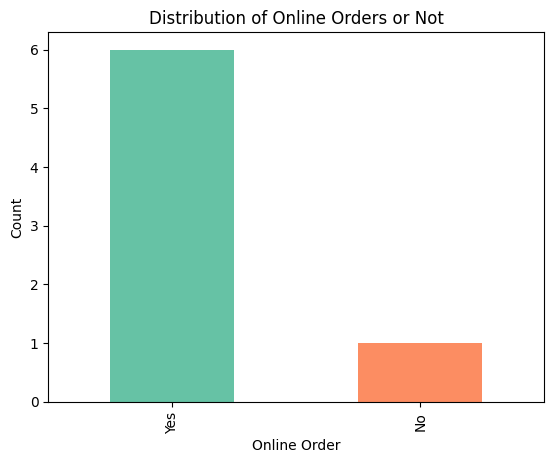

In [35]:
# Visualize the distribution of online orders
df['online_order'].value_counts().plot(kind='bar', color=sns.color_palette('Set2'))
plt.xlabel('Online Order')
plt.ylabel('Count')
plt.title('Distribution of Online Orders or Not')

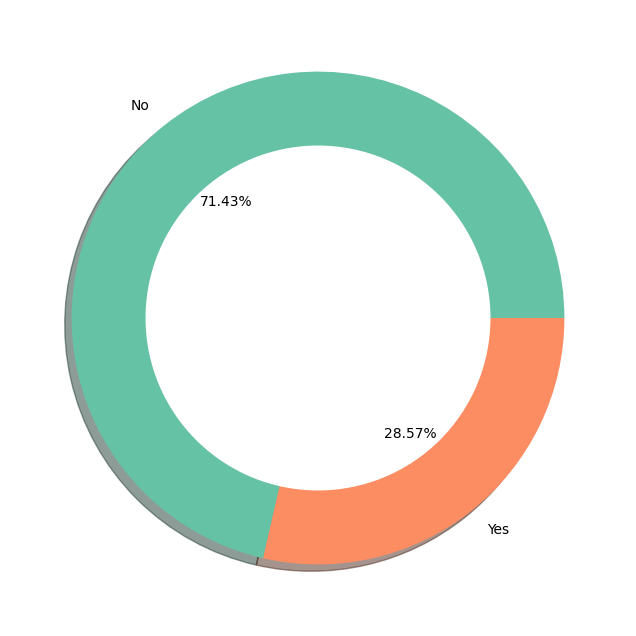

In [36]:
# Visualize the distribution of table booking
plt.figure(figsize=(8,8))
plt.pie(df['book_table'].value_counts().values, labels=df['book_table'].value_counts().index, autopct='%1.2f%%', shadow=True, colors=sns.color_palette('Set2'))
center_circle =plt.Circle((0,0), 0.7, fc='white')

fig = plt.gcf()# Get the current figure
fig.gca().add_artist(center_circle)# Add the center circle to the pie chart
plt.show()

In [37]:
# Analyze the distribution of locations
df['location'].value_counts()

location
Others    7
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Locations')

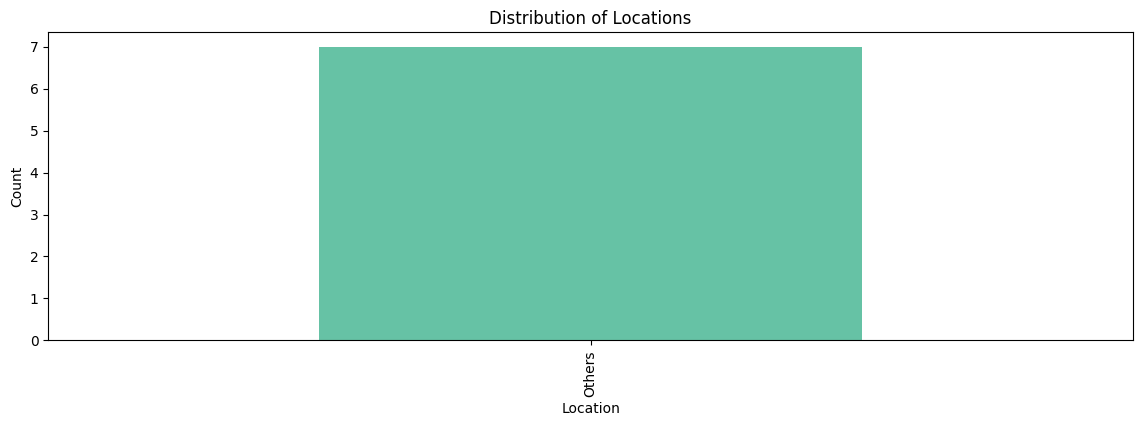

In [38]:
# Visualize the distribution of locations
plt.figure(figsize=(14,4))
df['location'].value_counts().plot(kind='bar', color=sns.color_palette('Set2'))
plt.xlabel('Location')
plt.ylabel('Count')
plt.title('Distribution of Locations')

Text(0.5, 1.0, 'Distribution of Restaurant Types')

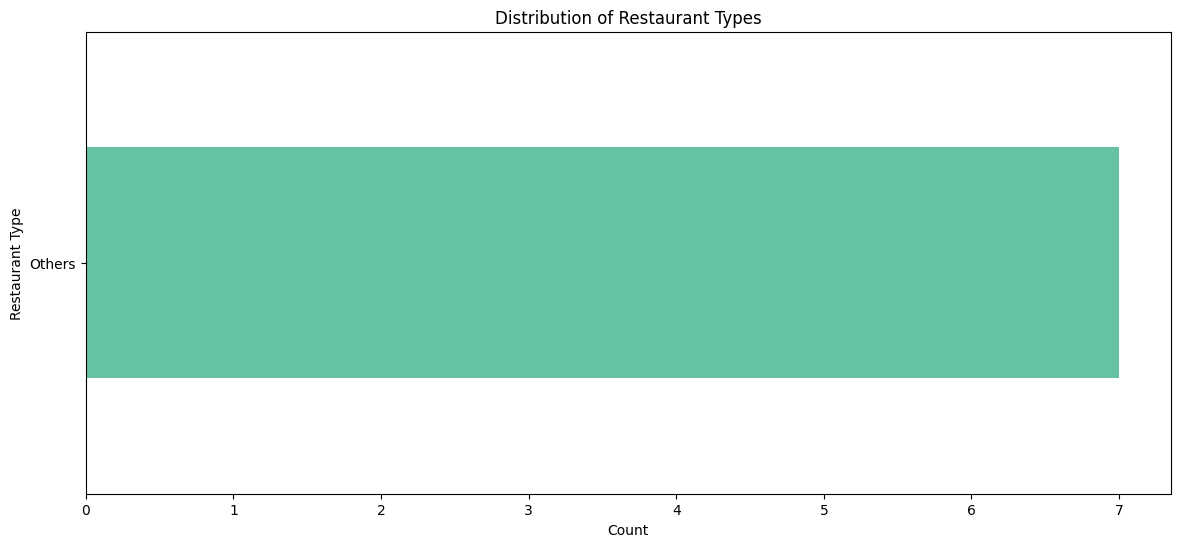

In [39]:
# Visualize the distribution of locations
plt.figure(figsize=(14,6))
df['rest_type'].value_counts().plot(kind='barh', color=sns.color_palette('Set2'))
plt.ylabel('Restaurant Type')
plt.xlabel('Count')
plt.title('Distribution of Restaurant Types')

/var/folders/yx/tdxdj0jd7b9dp8q2ddnc_llr0000gn/T/ipykernel_87853/572395586.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_df.sort_values(by=['Average Cost for 2 People'], ascending=False), x='Average Cost for 2 People', y='Restaurant Name', palette='Set2')


Text(0.5, 1.0, 'Average Cost for 2 People - Top 10 Restaurants')

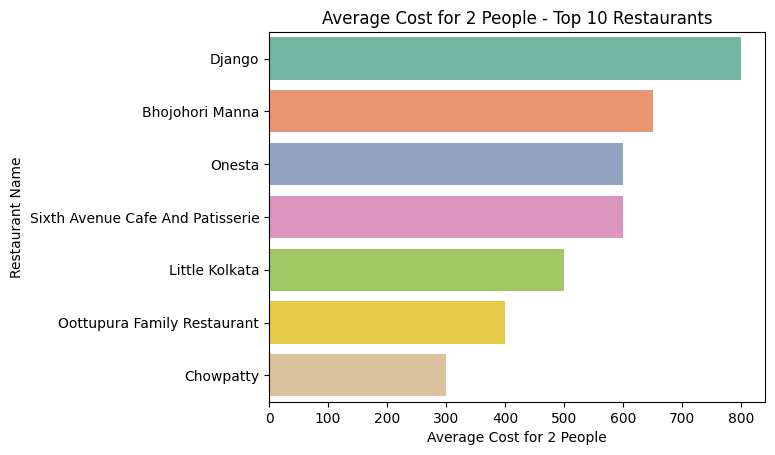

In [40]:
# Analyze the average cost for two people for the top 10 restaurants
res_cost = df['approx_cost(for two people)'].groupby(df['name'], sort=True)

dict1 = {}

for i,j in df['name'].value_counts()[:10].to_dict().items():
    dict1[i] = np.round(res_cost.get_group(i).mean(), 2)

cost_df =pd.DataFrame(list(dict1.items()), columns=['Restaurant Name', 'Average Cost for 2 People'])
sns.barplot(data=cost_df.sort_values(by=['Average Cost for 2 People'], ascending=False), x='Average Cost for 2 People', y='Restaurant Name', palette='Set2')
plt.title('Average Cost for 2 People - Top 10 Restaurants')

/var/folders/yx/tdxdj0jd7b9dp8q2ddnc_llr0000gn/T/ipykernel_87853/1468214935.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_df2.sort_values(by=['Average Rating'], ascending=False), x='Average Rating', y='Restaurant Name', palette='Set2')


Text(0.5, 1.0, 'Average Rating - Top 10 Restaurants')

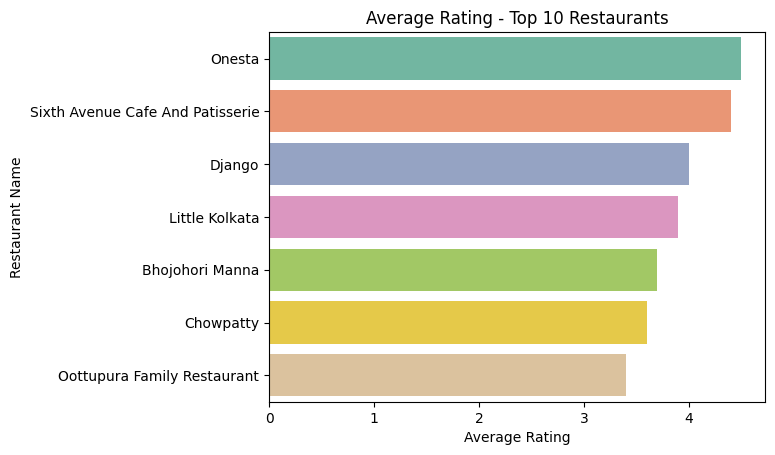

In [41]:
# Analyze the average rating for the top 10 restaurants
res_chain = df['rate'].groupby(df['name'], sort=True)

dict2 = {}

for i,j in df['name'].value_counts()[:10].to_dict().items():
    dict2[i] = np.round(res_chain.get_group(i).mean(), 2)

cost_df2 =pd.DataFrame(list(dict2.items()), columns=['Restaurant Name', 'Average Rating'])
sns.barplot(data=cost_df2.sort_values(by=['Average Rating'], ascending=False), x='Average Rating', y='Restaurant Name', palette='Set2')
plt.title('Average Rating - Top 10 Restaurants')